In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path
from dotenv import load_dotenv

load_dotenv()

# Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
COLORS = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B']

# Load semua dataset
RAW_DIR = Path("../data/raw")

df_enso     = pd.read_csv(RAW_DIR / "enso_index.csv", parse_dates=['tanggal'])
df_produksi = pd.read_csv(RAW_DIR / "produksi_padi.csv")
df_cuaca    = pd.read_csv(RAW_DIR / "cuaca_bmkg.csv")
df_harga    = pd.read_csv(RAW_DIR / "harga_beras.csv")
df_ndvi     = pd.read_csv(RAW_DIR / "ndvi_sentinel.csv")
df_irigasi  = pd.read_csv(RAW_DIR / "irigasi_pompanisasi.csv")
df_impor    = pd.read_csv(RAW_DIR / "impor_beras.csv")

print("✅ Semua dataset loaded!")
print(f"{'Dataset':<35} {'Shape':<15} {'Memory'}")
print("-" * 60)
datasets = {
    'ENSO Index': df_enso, 'Produksi Padi': df_produksi,
    'Cuaca BMKG': df_cuaca, 'Harga Beras': df_harga,
    'NDVI Sentinel': df_ndvi, 'Irigasi': df_irigasi,
    'Impor Beras': df_impor
}
for nama, df in datasets.items():
    mem = df.memory_usage(deep=True).sum() / 1024
    print(f"{nama:<35} {str(df.shape):<15} {mem:.1f} KB")

python-dotenv could not parse statement starting at line 1


✅ Semua dataset loaded!
Dataset                             Shape           Memory
------------------------------------------------------------
ENSO Index                          (420, 5)        36.2 KB
Produksi Padi                       (1624, 7)       317.5 KB
Cuaca BMKG                          (1680, 10)      295.4 KB
Harga Beras                         (1344, 7)       203.7 KB
NDVI Sentinel                       (5568, 7)       1111.3 KB
Irigasi                             (812, 10)       143.0 KB
Impor Beras                         (168, 8)        18.6 KB


In [2]:
print("=" * 60)
print("📊 EDA 1 — STATISTIK DESKRIPTIF UTAMA")
print("=" * 60)

# Produksi Padi
print("\n🌾 PRODUKSI PADI")
print(df_produksi[['luas_panen_ha', 'produktivitas_ton_per_ha', 'produksi_ton']].describe().round(2))

print("\n🌧️  CUACA BMKG")
print(df_cuaca[['curah_hujan_mm', 'suhu_rata_celsius', 'kelembaban_persen']].describe().round(2))

print("\n💰 HARGA BERAS")
print(df_harga[['harga_beras_medium_per_kg', 'harga_gabah_per_kg']].describe().round(2))

print("\n🛰️  NDVI SENTINEL")
print(df_ndvi[['ndvi']].describe().round(4))

# Missing values check
print("\n" + "=" * 60)
print("🔍 MISSING VALUES CHECK")
print("=" * 60)
for nama, df in datasets.items():
    missing = df.isnull().sum().sum()
    status = "✅ Bersih" if missing == 0 else f"⚠️  {missing} missing"
    print(f"{nama:<35} {status}")

📊 EDA 1 — STATISTIK DESKRIPTIF UTAMA

🌾 PRODUKSI PADI
       luas_panen_ha  produktivitas_ton_per_ha  produksi_ton
count        1624.00                   1624.00       1624.00
mean        15461.02                      5.69      87902.12
std          7306.48                      0.70      43109.30
min          3043.80                      4.08      14091.60
25%          9100.38                      5.14      52191.80
50%         15229.65                      5.66      85717.60
75%         21439.82                      6.23     120740.25
max         29988.50                      7.51     209617.00

🌧️  CUACA BMKG
       curah_hujan_mm  suhu_rata_celsius  kelembaban_persen
count         1680.00            1680.00            1680.00
mean           140.43              27.54              78.22
std             94.13               1.50               5.01
min              0.00              22.60              62.00
25%             59.48              26.50              74.70
50%            126.90

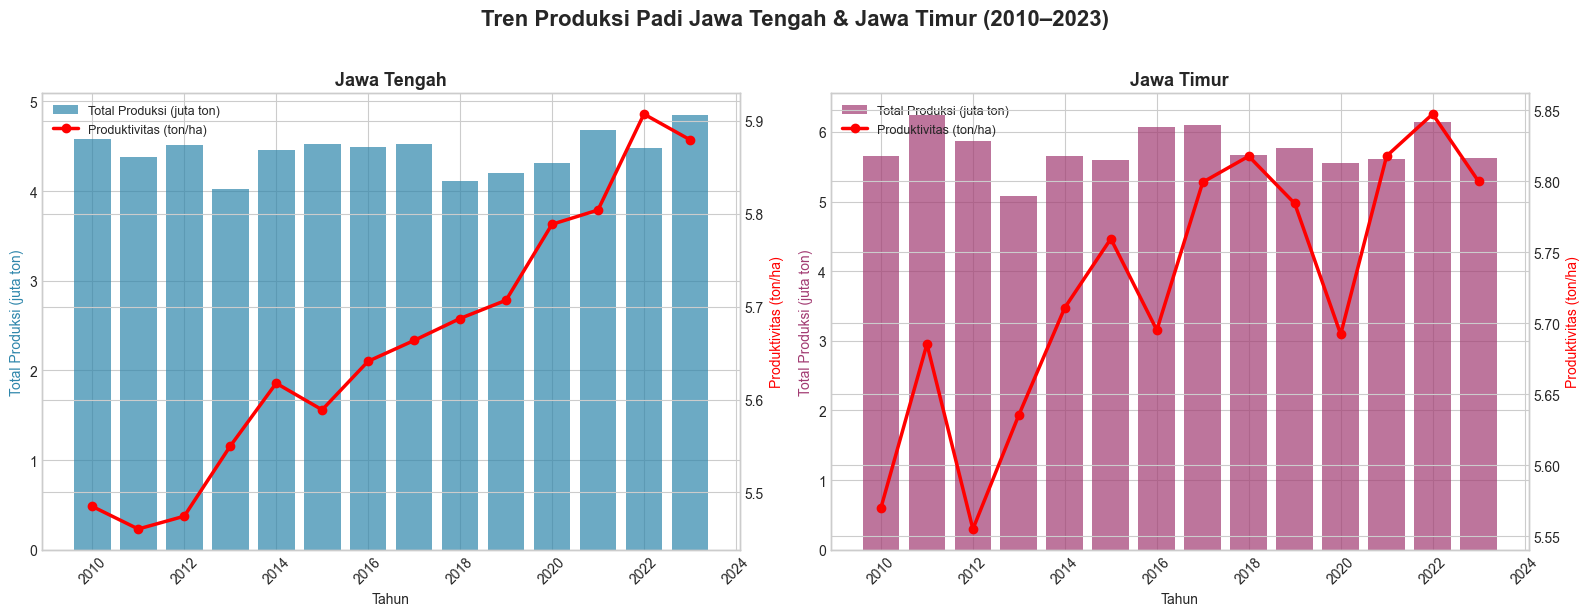

✅ Plot tersimpan!


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Tren Produksi Padi Jawa Tengah & Jawa Timur (2010–2023)', 
             fontsize=16, fontweight='bold', y=1.02)

for idx, provinsi in enumerate(['Jawa Tengah', 'Jawa Timur']):
    df_prov = df_produksi[df_produksi['provinsi'] == provinsi]
    tren = df_prov.groupby('tahun').agg(
        total_produksi=('produksi_ton', 'sum'),
        avg_produktivitas=('produktivitas_ton_per_ha', 'mean')
    ).reset_index()
    
    ax1 = axes[idx]
    ax2 = ax1.twinx()
    
    bars = ax1.bar(tren['tahun'], tren['total_produksi'] / 1e6, 
                   color=COLORS[idx], alpha=0.7, label='Total Produksi (juta ton)')
    line = ax2.plot(tren['tahun'], tren['avg_produktivitas'], 
                    color='red', marker='o', linewidth=2.5,
                    label='Produktivitas (ton/ha)')
    
    ax1.set_xlabel('Tahun')
    ax1.set_ylabel('Total Produksi (juta ton)', color=COLORS[idx])
    ax2.set_ylabel('Produktivitas (ton/ha)', color='red')
    ax1.set_title(f'{provinsi}', fontsize=13, fontweight='bold')
    ax1.tick_params(axis='x', rotation=45)
    
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('../data/processed/eda_tren_produksi.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot tersimpan!")

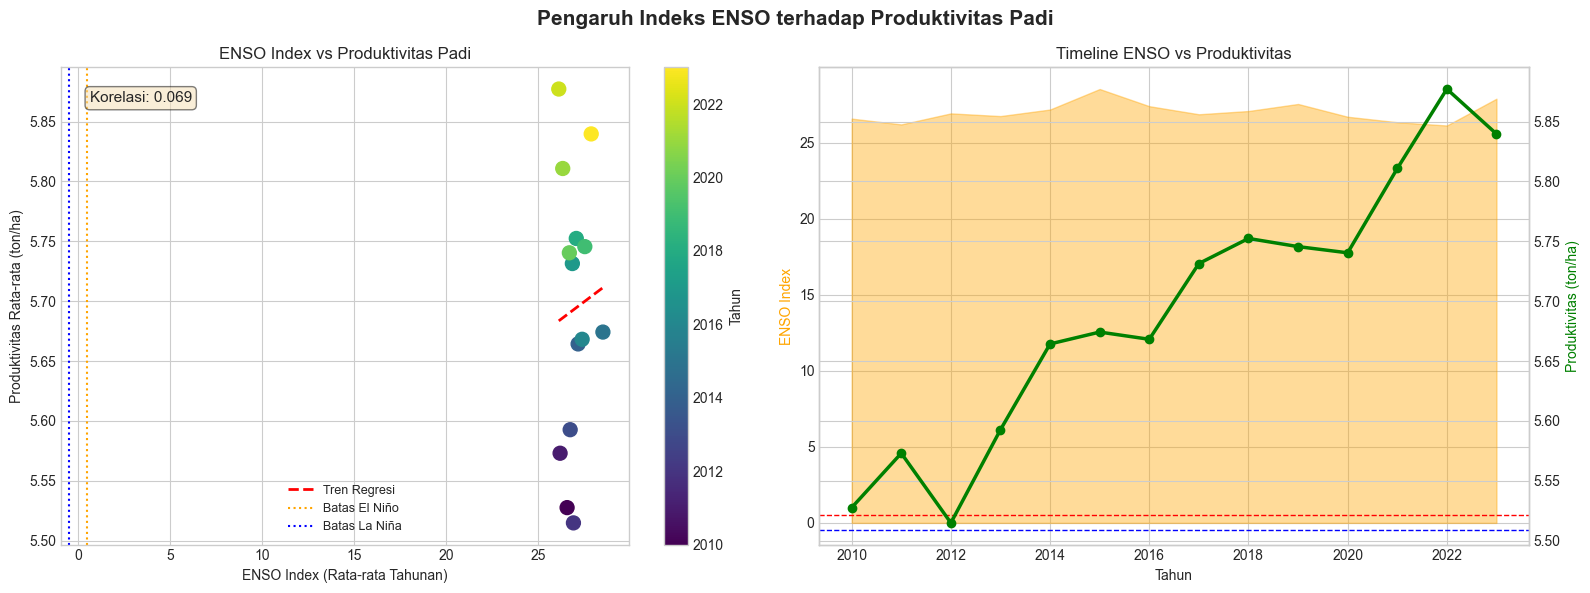

✅ Korelasi ENSO-Produktivitas: 0.069


In [4]:
# Gabungkan ENSO dengan produksi per tahun
enso_tahunan = df_enso.groupby('tahun')['enso_index'].mean().reset_index()
produksi_tahunan = df_produksi.groupby('tahun').agg(
    total_produksi=('produksi_ton', 'sum'),
    avg_produktivitas=('produktivitas_ton_per_ha', 'mean')
).reset_index()

df_merge_enso = pd.merge(produksi_tahunan, enso_tahunan, on='tahun')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Pengaruh Indeks ENSO terhadap Produktivitas Padi', 
             fontsize=15, fontweight='bold')

# Plot 1: Scatter ENSO vs Produktivitas
ax = axes[0]
scatter = ax.scatter(
    df_merge_enso['enso_index'], 
    df_merge_enso['avg_produktivitas'],
    c=df_merge_enso['tahun'], cmap='viridis', 
    s=100, zorder=5
)
# Garis regresi
z = np.polyfit(df_merge_enso['enso_index'], df_merge_enso['avg_produktivitas'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_merge_enso['enso_index'].min(), df_merge_enso['enso_index'].max(), 100)
ax.plot(x_line, p(x_line), 'r--', linewidth=2, label='Tren Regresi')
ax.axvline(x=0.5, color='orange', linestyle=':', linewidth=1.5, label='Batas El Niño')
ax.axvline(x=-0.5, color='blue', linestyle=':', linewidth=1.5, label='Batas La Niña')
plt.colorbar(scatter, ax=ax, label='Tahun')
ax.set_xlabel('ENSO Index (Rata-rata Tahunan)')
ax.set_ylabel('Produktivitas Rata-rata (ton/ha)')
ax.set_title('ENSO Index vs Produktivitas Padi')
ax.legend(fontsize=9)

# Korelasi
corr = df_merge_enso['enso_index'].corr(df_merge_enso['avg_produktivitas'])
ax.text(0.05, 0.95, f'Korelasi: {corr:.3f}', transform=ax.transAxes,
        fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 2: Timeline ENSO & Produktivitas
ax2 = axes[1]
ax2_twin = ax2.twinx()
ax2.fill_between(df_merge_enso['tahun'], df_merge_enso['enso_index'],
                 alpha=0.4, color='orange', label='ENSO Index')
ax2.axhline(y=0.5, color='red', linestyle='--', linewidth=1)
ax2.axhline(y=-0.5, color='blue', linestyle='--', linewidth=1)
ax2_twin.plot(df_merge_enso['tahun'], df_merge_enso['avg_produktivitas'],
              'g-o', linewidth=2.5, label='Produktivitas')
ax2.set_xlabel('Tahun')
ax2.set_ylabel('ENSO Index', color='orange')
ax2_twin.set_ylabel('Produktivitas (ton/ha)', color='green')
ax2.set_title('Timeline ENSO vs Produktivitas')

plt.tight_layout()
plt.savefig('../data/processed/eda_enso_produksi.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Korelasi ENSO-Produktivitas: {corr:.3f}")

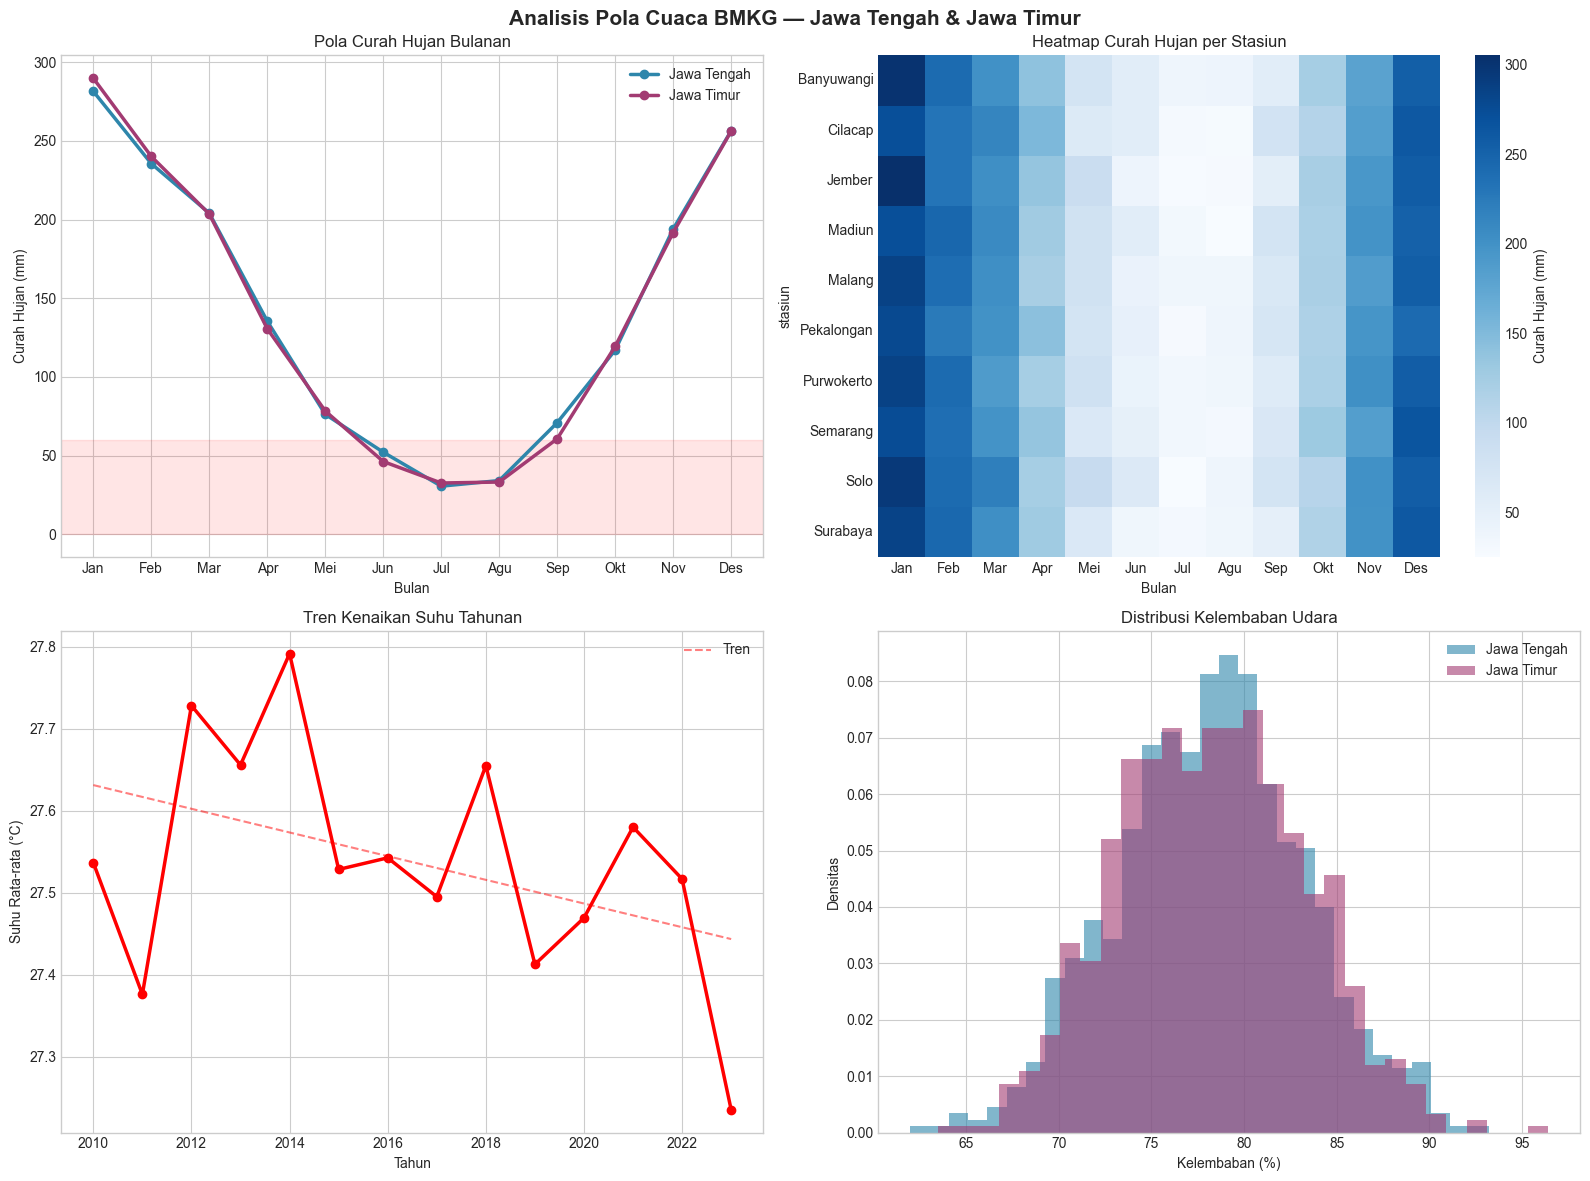

✅ Plot cuaca tersimpan!


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Analisis Pola Cuaca BMKG — Jawa Tengah & Jawa Timur', 
             fontsize=15, fontweight='bold')

# Plot 1: Curah hujan rata-rata per bulan per provinsi
ax = axes[0, 0]
for prov, color in zip(['Jawa Tengah', 'Jawa Timur'], COLORS):
    data = df_cuaca[df_cuaca['provinsi'] == prov].groupby('bulan')['curah_hujan_mm'].mean()
    ax.plot(data.index, data.values, marker='o', linewidth=2.5, 
            color=color, label=prov, markersize=6)
ax.set_xlabel('Bulan')
ax.set_ylabel('Curah Hujan (mm)')
ax.set_title('Pola Curah Hujan Bulanan')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des'])
ax.legend()
ax.axhspan(0, 60, alpha=0.1, color='red', label='Kering')

# Plot 2: Heatmap curah hujan per stasiun per bulan
ax = axes[0, 1]
pivot_hujan = df_cuaca.groupby(['stasiun', 'bulan'])['curah_hujan_mm'].mean().unstack()
sns.heatmap(pivot_hujan, ax=ax, cmap='Blues', 
            xticklabels=['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des'],
            cbar_kws={'label': 'Curah Hujan (mm)'})
ax.set_title('Heatmap Curah Hujan per Stasiun')
ax.set_xlabel('Bulan')

# Plot 3: Tren suhu rata-rata tahunan
ax = axes[1, 0]
suhu_trend = df_cuaca.groupby('tahun')['suhu_rata_celsius'].mean().reset_index()
ax.plot(suhu_trend['tahun'], suhu_trend['suhu_rata_celsius'], 
        'r-o', linewidth=2.5, markersize=6)
z = np.polyfit(suhu_trend['tahun'], suhu_trend['suhu_rata_celsius'], 1)
p = np.poly1d(z)
ax.plot(suhu_trend['tahun'], p(suhu_trend['tahun']), 'r--', alpha=0.5, label='Tren')
ax.set_xlabel('Tahun')
ax.set_ylabel('Suhu Rata-rata (°C)')
ax.set_title('Tren Kenaikan Suhu Tahunan')
ax.legend()

# Plot 4: Distribusi kelembaban
ax = axes[1, 1]
for prov, color in zip(['Jawa Tengah', 'Jawa Timur'], COLORS):
    data = df_cuaca[df_cuaca['provinsi'] == prov]['kelembaban_persen']
    ax.hist(data, bins=30, alpha=0.6, color=color, label=prov, density=True)
ax.set_xlabel('Kelembaban (%)')
ax.set_ylabel('Densitas')
ax.set_title('Distribusi Kelembaban Udara')
ax.legend()

plt.tight_layout()
plt.savefig('../data/processed/eda_cuaca.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot cuaca tersimpan!")

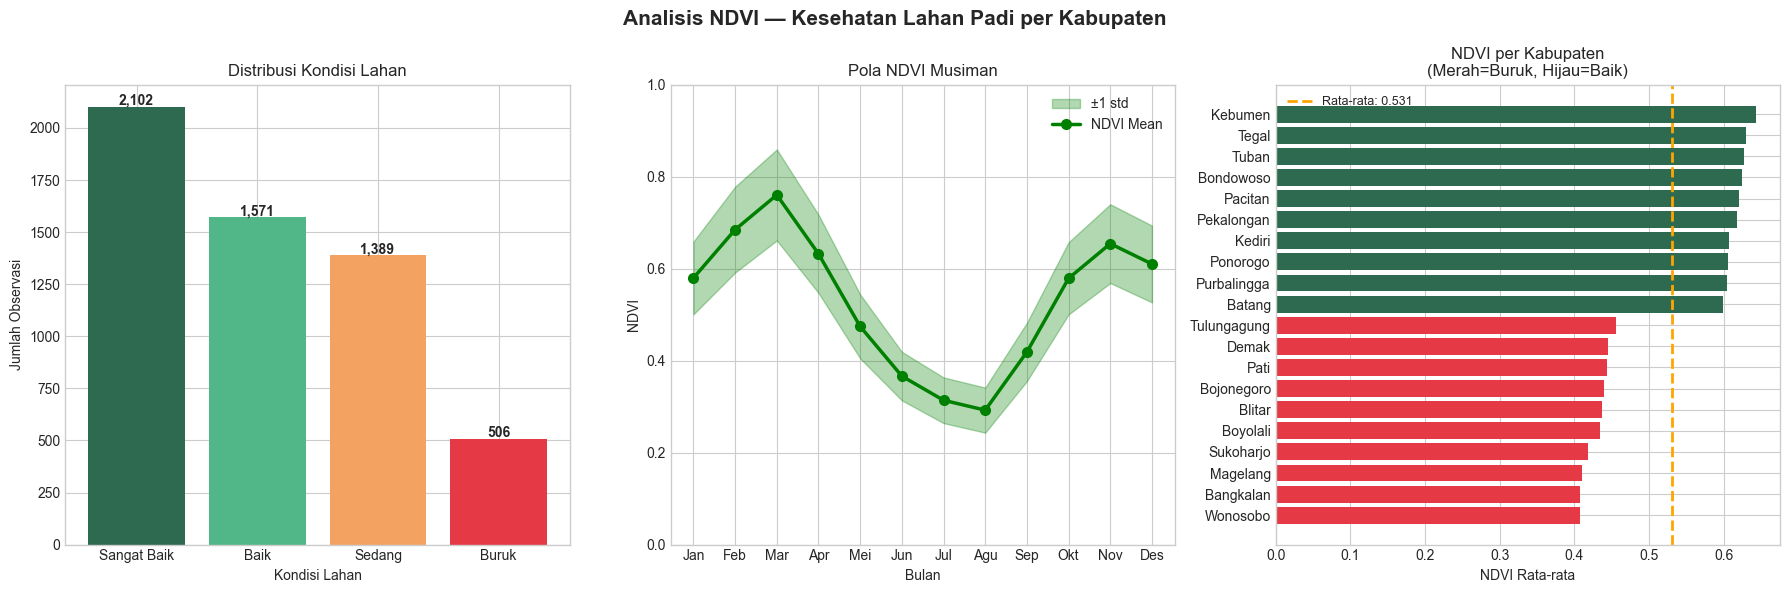

✅ Plot NDVI tersimpan!


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Analisis NDVI — Kesehatan Lahan Padi per Kabupaten', 
             fontsize=15, fontweight='bold')

# Plot 1: Distribusi NDVI per kondisi lahan
ax = axes[0]
kondisi_colors = {
    'Sangat Baik': '#2d6a4f',
    'Baik': '#52b788', 
    'Sedang': '#f4a261',
    'Buruk': '#e63946'
}
kondisi_counts = df_ndvi['kondisi_lahan'].value_counts()
bars = ax.bar(kondisi_counts.index, kondisi_counts.values,
              color=[kondisi_colors[k] for k in kondisi_counts.index])
ax.set_title('Distribusi Kondisi Lahan')
ax.set_xlabel('Kondisi Lahan')
ax.set_ylabel('Jumlah Observasi')
for bar, val in zip(bars, kondisi_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{val:,}', ha='center', fontsize=10, fontweight='bold')

# Plot 2: NDVI rata-rata per bulan (pola musiman)
ax = axes[1]
ndvi_bulanan = df_ndvi.groupby('bulan')['ndvi'].agg(['mean', 'std']).reset_index()
ax.fill_between(ndvi_bulanan['bulan'],
                ndvi_bulanan['mean'] - ndvi_bulanan['std'],
                ndvi_bulanan['mean'] + ndvi_bulanan['std'],
                alpha=0.3, color='green', label='±1 std')
ax.plot(ndvi_bulanan['bulan'], ndvi_bulanan['mean'], 
        'g-o', linewidth=2.5, markersize=7, label='NDVI Mean')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des'])
ax.set_xlabel('Bulan')
ax.set_ylabel('NDVI')
ax.set_title('Pola NDVI Musiman')
ax.legend()
ax.set_ylim(0, 1)

# Plot 3: Top 10 & Bottom 10 kabupaten berdasarkan NDVI
ax = axes[2]
ndvi_per_kab = df_ndvi.groupby('kabupaten')['ndvi'].mean().sort_values()
top_bottom = pd.concat([ndvi_per_kab.head(10), ndvi_per_kab.tail(10)])
colors_bar = ['#e63946'] * 10 + ['#2d6a4f'] * 10
ax.barh(top_bottom.index, top_bottom.values, color=colors_bar)
ax.axvline(x=ndvi_per_kab.mean(), color='orange', linestyle='--', 
           linewidth=2, label=f'Rata-rata: {ndvi_per_kab.mean():.3f}')
ax.set_xlabel('NDVI Rata-rata')
ax.set_title('NDVI per Kabupaten\n(Merah=Buruk, Hijau=Baik)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../data/processed/eda_ndvi.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot NDVI tersimpan!")

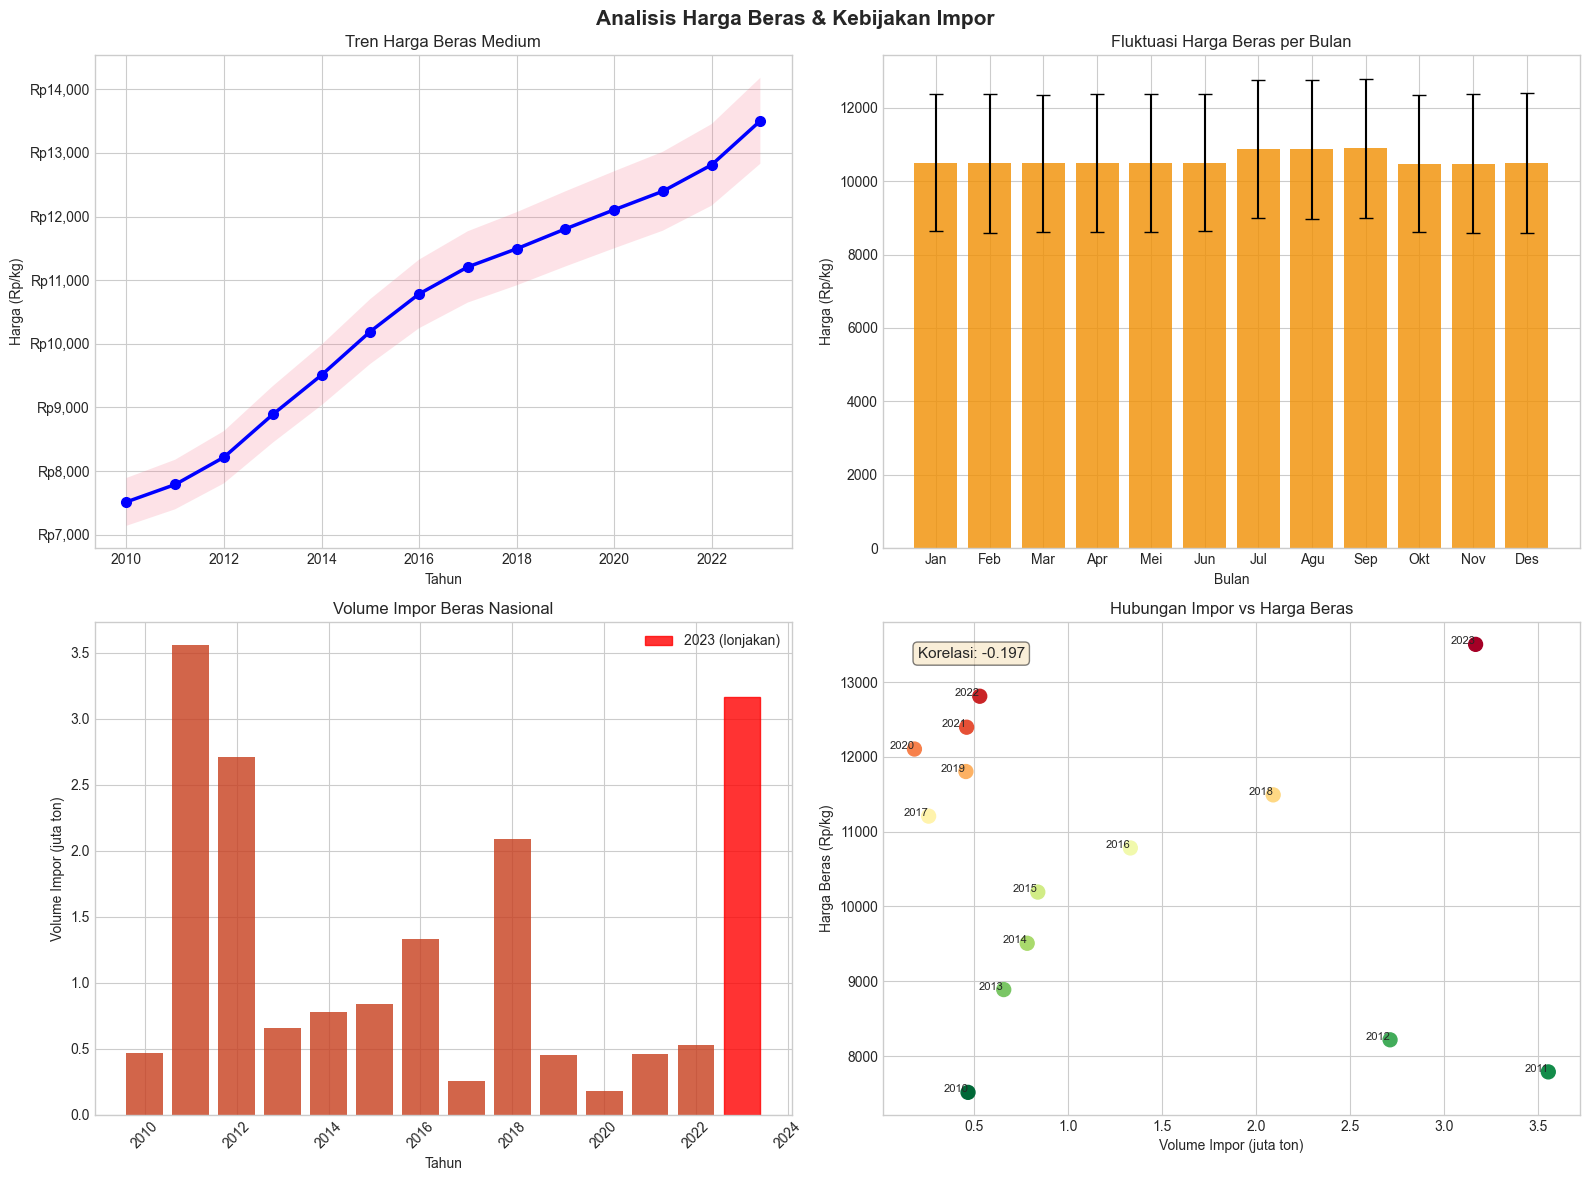

✅ Korelasi Impor-Harga: -0.197


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Analisis Harga Beras & Kebijakan Impor', 
             fontsize=15, fontweight='bold')

# Plot 1: Tren harga beras tahunan
ax = axes[0, 0]
harga_trend = df_harga.groupby('tahun')['harga_beras_medium_per_kg'].mean().reset_index()
ax.plot(harga_trend['tahun'], harga_trend['harga_beras_medium_per_kg'],
        'b-o', linewidth=2.5, markersize=7)
ax.fill_between(harga_trend['tahun'], 
                harga_trend['harga_beras_medium_per_kg'] * 0.95,
                harga_trend['harga_beras_medium_per_kg'] * 1.05,
                alpha=0.2)
ax.set_xlabel('Tahun')
ax.set_ylabel('Harga (Rp/kg)')
ax.set_title('Tren Harga Beras Medium')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'Rp{x:,.0f}'))

# Plot 2: Harga per bulan (pola musiman)
ax = axes[0, 1]
harga_bulanan = df_harga.groupby('bulan')['harga_beras_medium_per_kg'].agg(['mean','std'])
ax.bar(harga_bulanan.index, harga_bulanan['mean'],
       yerr=harga_bulanan['std'], capsize=5,
       color=COLORS[2], alpha=0.8)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des'])
ax.set_xlabel('Bulan')
ax.set_ylabel('Harga (Rp/kg)')
ax.set_title('Fluktuasi Harga Beras per Bulan')

# Plot 3: Volume impor tahunan
ax = axes[1, 0]
impor_trend = df_impor.groupby('tahun')['volume_impor_nasional_ton'].sum().reset_index()
bars = ax.bar(impor_trend['tahun'], 
              impor_trend['volume_impor_nasional_ton'] / 1e6,
              color=COLORS[3], alpha=0.8)
ax.set_xlabel('Tahun')
ax.set_ylabel('Volume Impor (juta ton)')
ax.set_title('Volume Impor Beras Nasional')
ax.tick_params(axis='x', rotation=45)
# Highlight 2023
bars[-1].set_color('red')
bars[-1].set_label('2023 (lonjakan)')
ax.legend()

# Plot 4: Korelasi impor vs harga
ax = axes[1, 1]
harga_tahunan = df_harga.groupby('tahun')['harga_beras_medium_per_kg'].mean().reset_index()
impor_tahunan = df_impor.groupby('tahun')['volume_impor_nasional_ton'].sum().reset_index()
df_merge_harga = pd.merge(harga_tahunan, impor_tahunan, on='tahun')

ax.scatter(df_merge_harga['volume_impor_nasional_ton']/1e6,
           df_merge_harga['harga_beras_medium_per_kg'],
           s=100, c=df_merge_harga['tahun'], cmap='RdYlGn_r')
for _, row in df_merge_harga.iterrows():
    ax.annotate(str(int(row['tahun'])),
                (row['volume_impor_nasional_ton']/1e6, row['harga_beras_medium_per_kg']),
                fontsize=8, ha='right')
ax.set_xlabel('Volume Impor (juta ton)')
ax.set_ylabel('Harga Beras (Rp/kg)')
ax.set_title('Hubungan Impor vs Harga Beras')

corr_impor_harga = df_merge_harga['volume_impor_nasional_ton'].corr(
    df_merge_harga['harga_beras_medium_per_kg'])
ax.text(0.05, 0.95, f'Korelasi: {corr_impor_harga:.3f}',
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('../data/processed/eda_harga_impor.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Korelasi Impor-Harga: {corr_impor_harga:.3f}")

🔗 Membuat dataset gabungan untuk analisis korelasi...


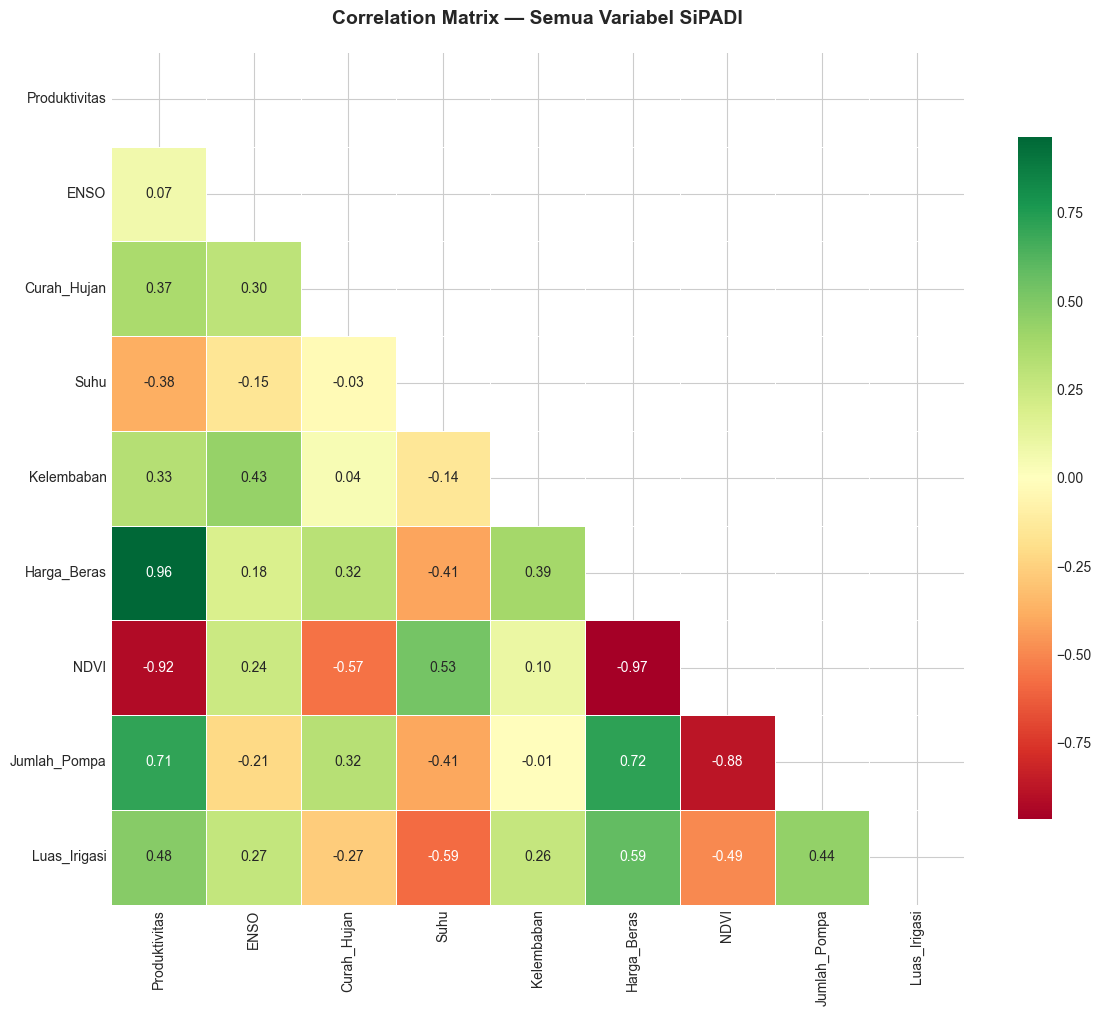

✅ Dataset gabungan tersimpan!

💡 KEY INSIGHTS DARI EDA

1. ENSO vs Produktivitas
   → Korelasi: 0.069
   → El Niño (ENSO > 0.5) cenderung menurunkan produktivitas
   
2. NDVI vs Produktivitas  
   → Korelasi: -0.917
   → NDVI tinggi = lahan sehat = produktivitas tinggi
   
3. Irigasi vs Produktivitas
   → Korelasi Pompa: 0.708
   → Pompanisasi berkorelasi positif dengan produktivitas
   
4. Impor vs Harga Beras
   → Korelasi: -0.197
   → Impor tinggi tidak selalu turunkan harga (lag effect)
   
5. Suhu vs Produktivitas
   → Korelasi: -0.385
   → Kenaikan suhu berdampak negatif pada produktivitas



In [8]:
# Buat dataset gabungan untuk correlation analysis
print("🔗 Membuat dataset gabungan untuk analisis korelasi...")

# Agregasi per tahun untuk merge
enso_yr = df_enso.groupby('tahun')['enso_index'].mean().reset_index()
produksi_yr = df_produksi.groupby('tahun').agg(
    avg_produktivitas=('produktivitas_ton_per_ha','mean'),
    total_produksi=('produksi_ton','sum'),
    total_luas=('luas_panen_ha','sum')
).reset_index()
cuaca_yr = df_cuaca.groupby('tahun').agg(
    avg_curah_hujan=('curah_hujan_mm','mean'),
    avg_suhu=('suhu_rata_celsius','mean'),
    avg_kelembaban=('kelembaban_persen','mean')
).reset_index()
harga_yr = df_harga.groupby('tahun')['harga_beras_medium_per_kg'].mean().reset_index()
ndvi_yr = df_ndvi.groupby('tahun')['ndvi'].mean().reset_index()
impor_yr = df_impor.groupby('tahun')['volume_impor_nasional_ton'].sum().reset_index()
irigasi_yr = df_irigasi.groupby('tahun').agg(
    avg_pompa=('jumlah_pompa_unit','mean'),
    avg_irigasi=('luas_irigasi_teknis_ha','mean')
).reset_index()

# Merge semua
df_combined = produksi_yr.copy()
for df_temp in [enso_yr, cuaca_yr, harga_yr, ndvi_yr, impor_yr, irigasi_yr]:
    df_combined = pd.merge(df_combined, df_temp, on='tahun', how='left')

# Rename kolom
df_combined = df_combined.rename(columns={
    'enso_index': 'ENSO',
    'avg_produktivitas': 'Produktivitas',
    'avg_curah_hujan': 'Curah_Hujan',
    'avg_suhu': 'Suhu',
    'avg_kelembaban': 'Kelembaban',
    'harga_beras_medium_per_kg': 'Harga_Beras',
    'ndvi': 'NDVI',
    'volume_impor_nasional_ton': 'Volume_Impor',
    'avg_pompa': 'Jumlah_Pompa',
    'avg_irigasi': 'Luas_Irigasi'
})

# Correlation Matrix
fig, ax = plt.subplots(figsize=(12, 10))
numeric_cols = ['Produktivitas', 'ENSO', 'Curah_Hujan', 'Suhu', 
                'Kelembaban', 'Harga_Beras', 'NDVI', 'Jumlah_Pompa', 'Luas_Irigasi']
corr_matrix = df_combined[numeric_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, ax=ax,
            square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
ax.set_title('Correlation Matrix — Semua Variabel SiPADI', 
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../data/processed/eda_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Simpan dataset gabungan untuk modelling
df_combined.to_csv('../data/processed/dataset_gabungan.csv', index=False)
print("✅ Dataset gabungan tersimpan!")

# Ringkasan insight
print("\n" + "=" * 60)
print("💡 KEY INSIGHTS DARI EDA")
print("=" * 60)
print(f"""
1. ENSO vs Produktivitas
   → Korelasi: {df_combined['ENSO'].corr(df_combined['Produktivitas']):.3f}
   → El Niño (ENSO > 0.5) cenderung menurunkan produktivitas
   
2. NDVI vs Produktivitas  
   → Korelasi: {df_combined['NDVI'].corr(df_combined['Produktivitas']):.3f}
   → NDVI tinggi = lahan sehat = produktivitas tinggi
   
3. Irigasi vs Produktivitas
   → Korelasi Pompa: {df_combined['Jumlah_Pompa'].corr(df_combined['Produktivitas']):.3f}
   → Pompanisasi berkorelasi positif dengan produktivitas
   
4. Impor vs Harga Beras
   → Korelasi: {df_combined['Volume_Impor'].corr(df_combined['Harga_Beras']):.3f}
   → Impor tinggi tidak selalu turunkan harga (lag effect)
   
5. Suhu vs Produktivitas
   → Korelasi: {df_combined['Suhu'].corr(df_combined['Produktivitas']):.3f}
   → Kenaikan suhu berdampak negatif pada produktivitas
""")